# Practical Session 07 &mdash; Kernels in practice

**Companion to Lecture&nbsp;07.** Third of three notebooks shared by Sessions&nbsp;06 and&nbsp;07.

| # | Notebook | Topic |
|---|----------|-------|
| 06a | The margin and the soft margin | the widest band, support vectors, $C$, the hinge |
| 06b | The dual and the kernel trick | the prices $\alpha_i$, KKT, inner products only &mdash; the bridge to Session&nbsp;07 |
| **07** | **Kernels in practice** | **valid kernels, the zoo, $\gamma$, kernel ridge regression (this notebook)** |

Notebook&nbsp;06b ended with a promise kept: replace the inner product by a kernel and the SVM bends. That
raises the questions of this session. **Which** functions are we allowed to put in? What do the common ones
*do*? How do we set their knobs without overfitting? And is the trick only for SVMs?

> &#11088; **Key idea.** A kernel is a similarity $K(\mathbf{x},\mathbf{x}')$ that secretly equals an inner
> product $\phi(\mathbf{x})^\top\phi(\mathbf{x}')$. That is guaranteed exactly when every Gram matrix it builds
> is **symmetric positive semi-definite**. And any method written with inner products only &mdash; SVMs,
> ridge regression, PCA &mdash; can use one.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons

from nb_utils import use_style
from nb_data import make_two_blobs, make_wave

use_style("notes")
C0, C1, CG = "#0072B2", "#D55E00", "#009E73"


def gram(A, B, kind, gamma=1.0, degree=3, c=1.0):
    "K(a, b) for every pair of rows of A and B -- the three kernels of the lecture"
    if kind == "linear":
        return A @ B.T
    if kind == "poly":
        return (A @ B.T + c) ** degree
    if kind == "rbf":
        sq = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T
        return np.exp(-gamma * np.maximum(sq, 0.0))
    raise ValueError(kind)

print("ready")

ready


## 1. What is allowed to be a kernel?

A kernel must behave like an inner product, and inner products have a property you can test on any finite
set of points. Build the Gram matrix $K_{ij}=K(\mathbf{x}_i,\mathbf{x}_j)$. If $K$ really is an inner
product, then for **every** vector of coefficients $\mathbf{c}$,

$$\mathbf{c}^\top K\,\mathbf{c}=\sum_{i,j}c_ic_j\,\phi(\mathbf{x}_i)^\top\phi(\mathbf{x}_j)
=\Big\lVert\sum_i c_i\,\phi(\mathbf{x}_i)\Big\rVert^2\ \ge\ 0 ,$$

because a squared length cannot be negative. A symmetric matrix with $\mathbf{c}^\top K\mathbf{c}\ge0$ for
every $\mathbf{c}$ is **positive semi-definite** (PSD) &mdash; equivalently, **all of its eigenvalues are
$\ge0$**. Mercer's theorem gives the converse: if every Gram matrix is symmetric PSD, some $\phi$ exists,
even if we never write it down.

So the test is concrete: build a Gram matrix and look at its smallest eigenvalue. Two cautions. On a
computer an exact $0$ comes out as a tiny $\pm10^{-14}$ from round-off, so only a *clearly* negative
eigenvalue counts. And the test is one-sided: a negative eigenvalue on **any** set of points proves a
function is not a kernel, but passing on one set is only evidence &mdash; Mercer asks for **every** finite set.

In [2]:
rng = np.random.default_rng(0)
P = rng.normal(size=(60, 2))
sqdist = (P ** 2).sum(1)[:, None] + (P ** 2).sum(1)[None, :] - 2 * P @ P.T

candidates = {
    "linear     x.z":             gram(P, P, "linear"),
    "polynomial (x.z + 1)^3":     gram(P, P, "poly", degree=3),
    "RBF        exp(-||x-z||^2)": gram(P, P, "rbf", gamma=1.0),
    "sum        linear + RBF":    gram(P, P, "linear") + gram(P, P, "rbf"),
    "product    poly x RBF":      gram(P, P, "poly", degree=2) * gram(P, P, "rbf"),
    "distance   ||x - z||":       np.sqrt(np.maximum(sqdist, 0.0)),
    "sigmoid    tanh(2 x.z - 1)": np.tanh(2 * gram(P, P, "linear") - 1),
}
for name, K in candidates.items():
    eig = np.linalg.eigvalsh(K)
    ok = eig.min() >= -1e-10 * np.abs(eig).max()   # round-off: "negative" must mean clearly negative
    print(f"{name:28s} | symmetric {str(np.allclose(K, K.T)):5s} | smallest eigenvalue {eig.min():11.3e} | "
          + ("PSD here: consistent with a kernel" if ok else "NOT PSD: not a kernel"))

linear     x.z               | symmetric True  | smallest eigenvalue  -1.418e-14 | PSD here: consistent with a kernel
polynomial (x.z + 1)^3       | symmetric True  | smallest eigenvalue  -1.875e-13 | PSD here: consistent with a kernel
RBF        exp(-||x-z||^2)   | symmetric True  | smallest eigenvalue   6.022e-09 | PSD here: consistent with a kernel
sum        linear + RBF      | symmetric True  | smallest eigenvalue   6.143e-09 | PSD here: consistent with a kernel
product    poly x RBF        | symmetric True  | smallest eigenvalue   1.510e-07 | PSD here: consistent with a kernel
distance   ||x - z||         | symmetric True  | smallest eigenvalue  -3.179e+01 | NOT PSD: not a kernel
sigmoid    tanh(2 x.z - 1)   | symmetric True  | smallest eigenvalue  -2.373e+01 | NOT PSD: not a kernel


In [3]:
K_bad = candidates["distance   ||x - z||"]
eigval, eigvec = np.linalg.eigh(K_bad)
c = eigvec[:, 0]                                  # the direction of the most negative eigenvalue
print(f"distance 'kernel':  c^T K c = {c @ K_bad @ c:.3f}   <-- a squared length cannot be negative,")
print("so no feature map phi can reproduce ||x - z|| as an inner product.")

K_rbf = candidates["RBF        exp(-||x-z||^2)"]
c_rbf = np.linalg.eigh(K_rbf)[1][:, 0]            # the RBF's own worst direction
print(f"\nRBF: even its worst direction gives c^T K c = {c_rbf @ K_rbf @ c_rbf:.1e} >= 0")
print("(random vectors c almost never hit the worst direction -- that is why we test eigenvalues)")

distance 'kernel':  c^T K c = -31.786   <-- a squared length cannot be negative,
so no feature map phi can reproduce ||x - z|| as an inner product.

RBF: even its worst direction gives c^T K c = 6.0e-09 >= 0
(random vectors c almost never hit the worst direction -- that is why we test eigenvalues)


## 2. The Gram matrix is a similarity map

A kernel method never sees the points themselves &mdash; only the $n\times n$ Gram matrix. For the RBF kernel,
$K_{ij}$ is near $1$ when $\mathbf{x}_i$ and $\mathbf{x}_j$ are close and near $0$ when they are far. Sort
the points by class and the class structure shows up as bright blocks. Shuffle them and the structure is
still there &mdash; invisible to *us*, but not to the algorithm.

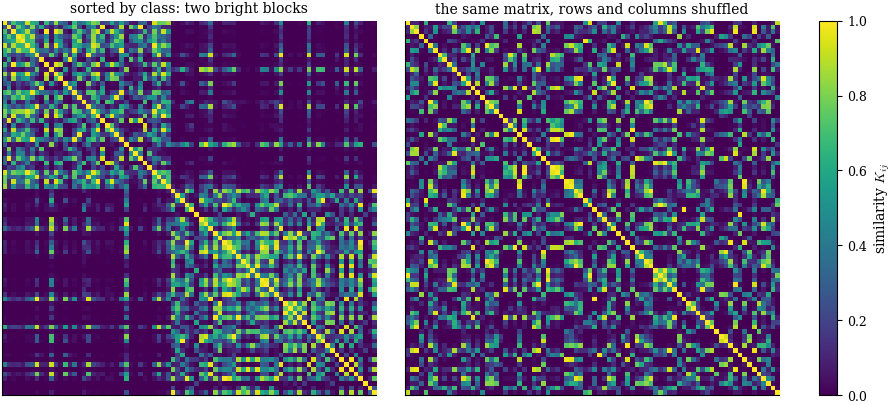

In [4]:
Xg, yg = make_two_blobs(n=80, sep=1.6, seed=2)
by_class = np.argsort(yg, kind="stable")
shuffled = np.random.default_rng(1).permutation(len(yg))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.1))
for ax, idx, ttl in ((axes[0], by_class, "sorted by class: two bright blocks"),
                     (axes[1], shuffled, "the same matrix, rows and columns shuffled")):
    im = ax.imshow(gram(Xg[idx], Xg[idx], "rbf", gamma=0.5), vmin=0, vmax=1, cmap="viridis")
    ax.set_title(ttl, fontsize=10); ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.03, label="similarity $K_{ij}$")
plt.show()

## 3. The kernel zoo, and why the RBF is infinite-dimensional

| kernel | formula | what it does |
|---|---|---|
| linear | $\mathbf{x}^\top\mathbf{x}'$ | the plain SVM of notebook&nbsp;06a |
| polynomial | $(c+\mathbf{x}^\top\mathbf{x}')^d$ | every product of features up to degree $d$ &mdash; a **global** reach |
| RBF | $\exp(-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2)$ | a **local** bump, about $1/\sqrt\gamma$ wide |

The RBF feature map has infinitely many coordinates, and in one dimension you can write it down. Expand
$e^{-\gamma(x-z)^2}=e^{-\gamma x^2}\,e^{-\gamma z^2}\,e^{2\gamma xz}$ and use the power series of the last
factor:

$$\phi_k(x)=e^{-\gamma x^2}\sqrt{\frac{(2\gamma)^k}{k!}}\;x^k,\qquad k=0,1,2,\dots$$

Keeping only the first $D$ coordinates gives an approximation that improves as $D$ grows. Any finite $D$ is
only an approximation &mdash; on points close to the origin it converges fast, as the table shows.

D =  1 coordinates:  max |phi(x).phi(z) - K(x, z)| = 9.8e-01
D =  2 coordinates:  max |phi(x).phi(z) - K(x, z)| = 9.1e-01
D =  4 coordinates:  max |phi(x).phi(z) - K(x, z)| = 5.7e-01
D =  8 coordinates:  max |phi(x).phi(z) - K(x, z)| = 5.1e-02
D = 16 coordinates:  max |phi(x).phi(z) - K(x, z)| = 4.9e-06
D = 32 coordinates:  max |phi(x).phi(z) - K(x, z)| = 5.6e-16


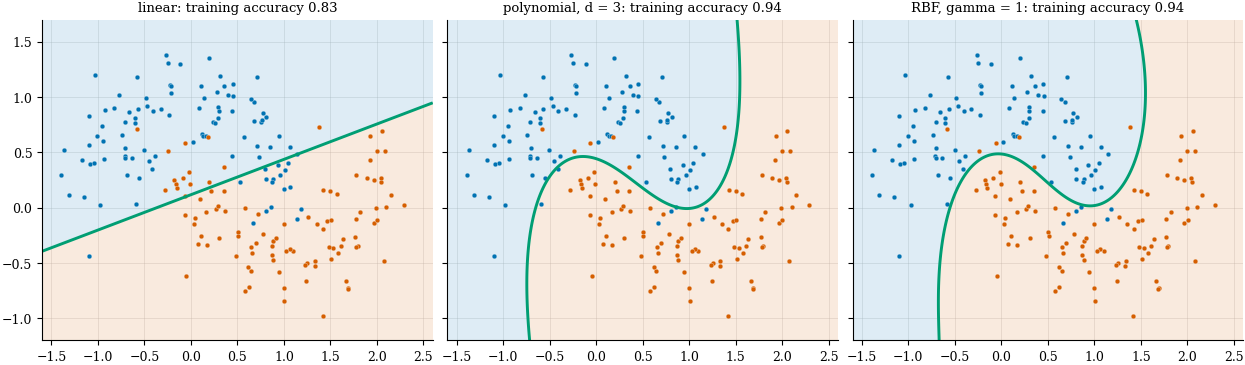

In [5]:
from math import factorial


def phi_rbf_1d(x, gamma, D):
    "the first D coordinates of the 1-D RBF feature map"
    k = np.arange(D)
    coef = np.sqrt((2 * gamma) ** k / np.array([factorial(int(j)) for j in k], float))
    return np.exp(-gamma * x ** 2)[:, None] * coef[None, :] * x[:, None] ** k[None, :]


x_pts = np.linspace(-2, 2, 41)
K_true = gram(x_pts[:, None], x_pts[:, None], "rbf", gamma=0.5)
for D in (1, 2, 4, 8, 16, 32):
    F = phi_rbf_1d(x_pts, 0.5, D)
    print(f"D = {D:2d} coordinates:  max |phi(x).phi(z) - K(x, z)| = {np.abs(F @ F.T - K_true).max():.1e}")

Xm, ym = make_moons(n_samples=200, noise=0.22, random_state=0)
ym = np.where(ym == 1, 1, -1)
gx, gy = np.meshgrid(np.linspace(-1.6, 2.6, 250), np.linspace(-1.2, 1.7, 250))
G = np.column_stack([gx.ravel(), gy.ravel()])


def draw_regions(ax, model, title):
    Z = model.decision_function(G).reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=[Z.min() - 1, 0, Z.max() + 1], colors=[C0, C1], alpha=0.13)
    ax.contour(gx, gy, Z, levels=[0], colors=CG, linewidths=2.1)
    for lab, c in ((-1, C0), (1, C1)):
        ax.scatter(*Xm[ym == lab].T, s=12, color=c, edgecolor="white", linewidth=0.2)
    ax.set_title(title, fontsize=9.5)


fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), sharey=True)
for ax, (name, params) in zip(axes, [("linear", dict(kernel="linear")),
                                     ("polynomial, d = 3", dict(kernel="poly", degree=3, gamma=1.0, coef0=1.0)),
                                     ("RBF, gamma = 1", dict(kernel="rbf", gamma=1.0))]):
    s = SVC(C=1.0, **params).fit(Xm, ym)
    draw_regions(ax, s, f"{name}: training accuracy {s.score(Xm, ym):.2f}")
plt.show()

## 4. $\gamma$ is the complexity dial

The RBF bump is about $1/\sqrt\gamma$ wide. With **small** $\gamma$ every point influences a wide
neighborhood and the boundary is nearly straight &mdash; underfitting. With **large** $\gamma$ each point
becomes an island and the boundary wraps individual points &mdash; overfitting. Training accuracy keeps
climbing as $\gamma$ grows, so it cannot choose $\gamma$; cross-validation can. And $\gamma$ interacts with
$C$, so the two are tuned **together**.

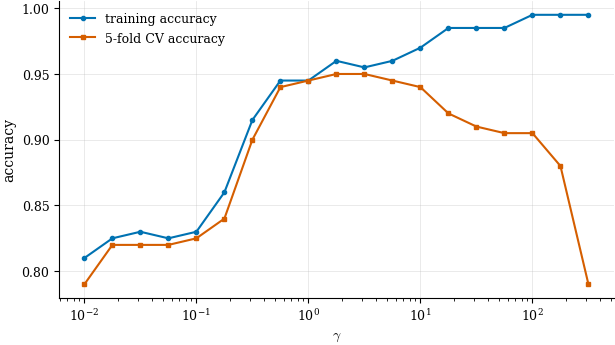

best gamma by cross-validation: 1.78


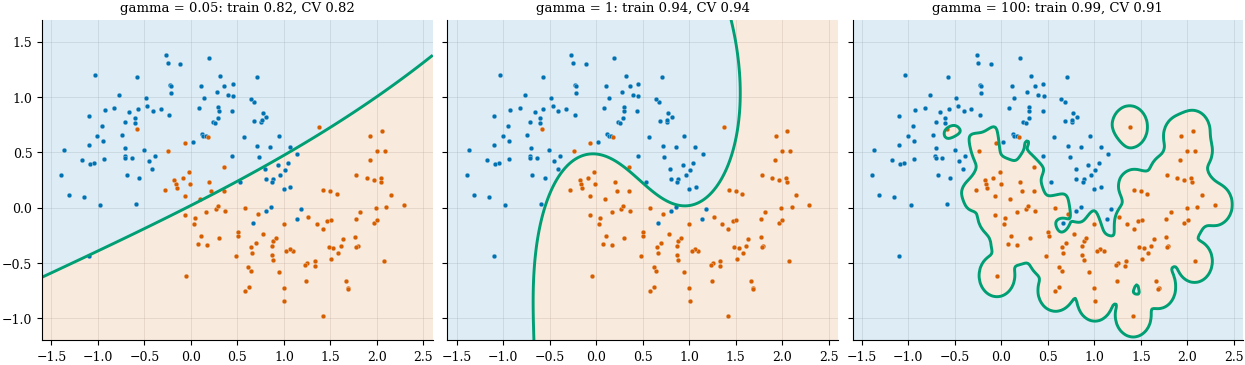

In [6]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

gammas = np.logspace(-2, 2.5, 19)
train_acc, cv_acc = [], []
for g in gammas:
    s = SVC(kernel="rbf", gamma=g, C=1.0)
    train_acc.append(s.fit(Xm, ym).score(Xm, ym))
    cv_acc.append(cross_val_score(s, Xm, ym, cv=5).mean())

fig, ax = plt.subplots(figsize=(6.2, 3.5))
ax.semilogx(gammas, train_acc, "-o", ms=3, color=C0, label="training accuracy")
ax.semilogx(gammas, cv_acc, "-s", ms=3, color=C1, label="5-fold CV accuracy")
ax.set_xlabel(r"$\gamma$"); ax.set_ylabel("accuracy"); ax.legend(fontsize=9)
plt.show()
print(f"best gamma by cross-validation: {gammas[int(np.argmax(cv_acc))]:.3g}")

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), sharey=True)
for ax, g in zip(axes, (0.05, 1.0, 100.0)):                      # <-- CHANGE ME
    s = SVC(kernel="rbf", gamma=g, C=1.0).fit(Xm, ym)
    draw_regions(ax, s, f"gamma = {g:g}: train {s.score(Xm, ym):.2f}, "
                        f"CV {cross_val_score(s, Xm, ym, cv=5).mean():.2f}")
plt.show()

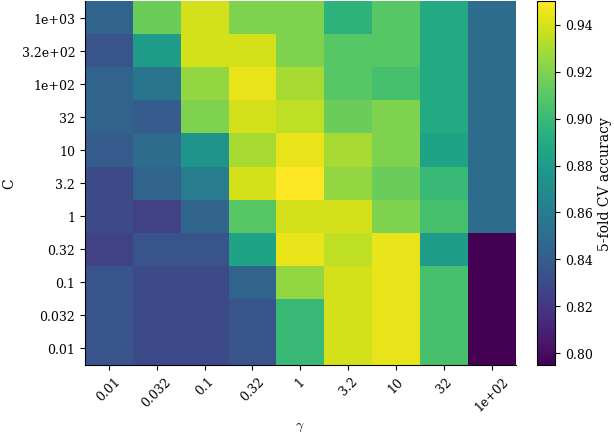

best: {'C': 3.16, 'gamma': 1.0}   CV accuracy 0.950
The good region is a diagonal band: a larger gamma can be offset by a smaller C, and vice versa.


In [7]:
Cs = np.logspace(-2, 3, 11)
gs = np.logspace(-2, 2, 9)
search = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel="rbf")),
                      {"svc__C": Cs, "svc__gamma": gs}, cv=5).fit(Xm, ym)
scores = search.cv_results_["mean_test_score"].reshape(len(Cs), len(gs))   # rows: C, columns: gamma

fig, ax = plt.subplots(figsize=(6.2, 4.4))
im = ax.imshow(scores, origin="lower", cmap="viridis", aspect="auto")
ax.set_xticks(range(len(gs)), [f"{g:.2g}" for g in gs], rotation=45)
ax.set_yticks(range(len(Cs)), [f"{c:.2g}" for c in Cs])
ax.set_xlabel(r"$\gamma$"); ax.set_ylabel("C"); ax.grid(False)
fig.colorbar(im, ax=ax, label="5-fold CV accuracy")
plt.show()
print("best:", {k.split("__")[1]: float(f"{v:.3g}") for k, v in search.best_params_.items()},
      f"  CV accuracy {search.best_score_:.3f}")
print("The good region is a diagonal band: a larger gamma can be offset by a smaller C, and vice versa.")

## 5. Beyond SVMs: kernel ridge regression

The **representer theorem** says that, for ridge-style problems, the best function is a weighted sum of
kernel bumps sitting at the training points,

$$f(\mathbf{x})=\sum_i\alpha_i\,K(\mathbf{x}_i,\mathbf{x}),$$

so the unknowns are again just $n$ numbers. These $\alpha_i$ are *not* the SVM prices of notebook&nbsp;06b:
they can be negative, they already carry the target, and there is no $b$. For squared loss plus a penalty
$\lambda$, setting the gradient to zero gives them in **closed form** &mdash; one linear solve and no optimizer:

$$\boldsymbol\alpha=(K+\lambda I)^{-1}\mathbf{y}.$$

> &#9888;&#65039; **Name clash.** scikit-learn's `KernelRidge` calls the penalty $\lambda$ `alpha`, and stores
> *our* $\boldsymbol\alpha$ in `dual_coef_`. Same numbers, swapped names.

The data are the noisy wave from Sessions&nbsp;02&ndash;03, where polynomials either underfit or exploded.

max |ours - sklearn prediction| = 2.4e-14
our alpha equals sklearn's dual_coef_: True


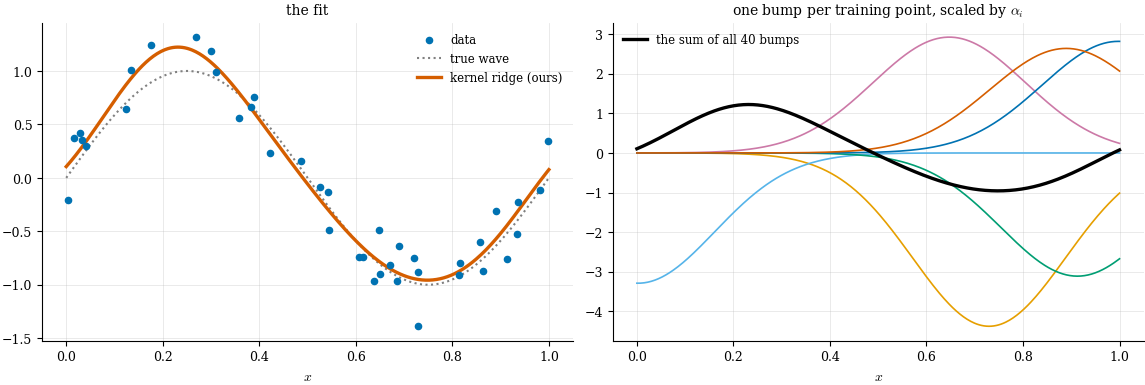

tallest single bump: 4.4, far taller than the fit itself -- neighboring bumps largely cancel.


In [8]:
from sklearn.kernel_ridge import KernelRidge

x, yw = make_wave(n=40, seed=0)
Xw = x[:, None]
gamma, lam = 20.0, 0.1

K = gram(Xw, Xw, "rbf", gamma=gamma)
alpha = np.linalg.solve(K + lam * np.eye(len(x)), yw)      # (K + lambda I) alpha = y

xs = np.linspace(0, 1, 400)[:, None]
f_ours = gram(xs, Xw, "rbf", gamma=gamma) @ alpha           # f(x) = sum_i alpha_i K(x_i, x)

krr = KernelRidge(kernel="rbf", gamma=gamma, alpha=lam).fit(Xw, yw)
print(f"max |ours - sklearn prediction| = {np.abs(f_ours - krr.predict(xs)).max():.1e}")
print(f"our alpha equals sklearn's dual_coef_: {np.allclose(alpha, krr.dual_coef_)}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.9))
a1.scatter(x, yw, s=20, color=C0, zorder=3, label="data")
a1.plot(xs, np.sin(2 * np.pi * xs), ":", color="0.5", label="true wave")
a1.plot(xs, f_ours, color=C1, lw=2.4, label="kernel ridge (ours)")
a1.set_xlabel("$x$"); a1.legend(fontsize=8.5); a1.set_title("the fit", fontsize=10)
bump_colors = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#0072B2", "#D55E00"]
for color, i in zip(bump_colors, np.argsort(-np.abs(alpha))[:6]):   # the six largest bumps
    a2.plot(xs, alpha[i] * gram(xs, Xw[i:i + 1], "rbf", gamma=gamma), lw=1.2, color=color)
a2.plot(xs, f_ours, color="black", lw=2.4, label="the sum of all 40 bumps")
a2.set_xlabel("$x$"); a2.legend(fontsize=8.5)
a2.set_title(r"one bump per training point, scaled by $\alpha_i$", fontsize=10)
plt.show()
print(f"tallest single bump: {np.abs(alpha).max():.1f}, far taller than the fit itself "
      "-- neighboring bumps largely cancel.")

In [9]:
# with the LINEAR kernel, kernel ridge must be Session 03's ridge regression in disguise
rng2 = np.random.default_rng(3)
Xl = rng2.normal(size=(50, 4))
yl = Xl @ np.array([1.5, -2.0, 0.5, 3.0]) + rng2.normal(0, 0.3, 50)
lam = 2.0

w_primal = np.linalg.solve(Xl.T @ Xl + lam * np.eye(4), Xl.T @ yl)     # Session 03: a 4 x 4 solve
alpha_l = np.linalg.solve(Xl @ Xl.T + lam * np.eye(50), yl)             # this session: a 50 x 50 solve
w_dual = Xl.T @ alpha_l                                                 # w = sum_i alpha_i x_i

print("ridge (Session 03)       w =", w_primal.round(6))
print("kernel ridge, linear K   w =", w_dual.round(6))
print("identical:", np.allclose(w_primal, w_dual))
print("\nA 4x4 solve and a 50x50 solve give the same model.")
print("With an RBF kernel (an infinite feature map), only the 50x50 one exists.")

ridge (Session 03)       w = [ 1.417979 -1.916064  0.443975  2.801651]
kernel ridge, linear K   w = [ 1.417979 -1.916064  0.443975  2.801651]
identical: True

A 4x4 solve and a 50x50 solve give the same model.
With an RBF kernel (an infinite feature map), only the 50x50 one exists.


## 6. Real data: does a kernel help?

On the **diabetes** data from Sessions&nbsp;02&ndash;03 (442 patients, 10 features) we compare ordinary
ridge with RBF kernel ridge, tune each by cross-validation, and score each once on a held-out test set.
Expect an honest answer rather than a triumphant one.

In [10]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

Xd, yd = load_diabetes(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25, random_state=0)

ridge = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
                     {"ridge__alpha": np.logspace(-3, 3, 13)}, cv=5).fit(Xtr, ytr)

y_mean = ytr.mean()                    # KernelRidge has no intercept, so center the target ourselves
kridge = GridSearchCV(make_pipeline(StandardScaler(), KernelRidge(kernel="rbf")),
                      {"kernelridge__alpha": np.logspace(-3, 1, 9),
                       "kernelridge__gamma": np.logspace(-4, 0, 9)}, cv=5).fit(Xtr, ytr - y_mean)

rmse = {"predict the mean  ": root_mean_squared_error(yte, np.full_like(yte, y_mean)),
        "ridge (linear)    ": root_mean_squared_error(yte, ridge.predict(Xte)),
        "kernel ridge (RBF)": root_mean_squared_error(yte, kridge.predict(Xte) + y_mean)}
for name, value in rmse.items():
    print(f"{name}  test RMSE {value:6.2f}")
short = lambda d: {k.split("__")[1]: float(f"{v:.3g}") for k, v in d.items()}
print("\nchosen by CV:  ridge", short(ridge.best_params_), "  kernel ridge", short(kridge.best_params_))

predict the mean    test RMSE  70.46
ridge (linear)      test RMSE  56.11
kernel ridge (RBF)  test RMSE  56.84

chosen by CV:  ridge {'alpha': 31.6}   kernel ridge {'alpha': 1.0, 'gamma': 0.0316}


## Recap & exercises

**Recap.**
* A function is a valid kernel exactly when every Gram matrix it builds is **symmetric PSD** (Mercer). A
  clearly negative eigenvalue on any point set rules a function out; passing on one set is only evidence.
  The distance $\lVert\mathbf{x}-\mathbf{z}\rVert$ and the `tanh` "kernel" fail; sums and products of kernels pass.
* The Gram matrix is a **similarity map**, and it is all a kernel method ever sees.
* **Linear** is straight and global, **polynomial** mixes feature products up to degree $d$, **RBF** is a
  local bump whose feature map is infinite &mdash; any finite truncation only approximates it.
* **$\gamma$** is a complexity dial. Training accuracy cannot set it: cross-validate $\gamma$ and $C$ together.
* The **representer theorem** makes the solution a sum of $n$ bumps; for ridge the weights come from one
  solve, $\boldsymbol\alpha=(K+\lambda I)^{-1}\mathbf{y}$, matched to scikit-learn.
* With a linear kernel, kernel ridge *is* Session&nbsp;03's ridge &mdash; an $n\times n$ solve instead of a
  $d\times d$ one.

**Exercises.**
1. In &sect;1, look for values $a,c$ for which $\tanh(a\,\mathbf{x}^\top\mathbf{z}+c)$ **passes** the eigenvalue
   test on these 60 points. Would that make it a kernel?
2. In &sect;3, spread the points over $[-6,6]$ instead of $[-2,2]$. How many coordinates $D$ does the truncated
   RBF map need now, and why?
3. In &sect;4, repeat the $\gamma$ sweep with $C=100$. Where does the best $\gamma$ move?
4. In &sect;5, set $\lambda=10^{-6}$ and then $\lambda=10$. Describe both fits in terms of the bumps.
5. In &sect;6, add a polynomial kernel ridge to the comparison. Does it beat the RBF on this dataset?

*This closes the SVM and kernels series.* Next session: **decision trees**.